In [ ]:
import numpy as np


class DirectedGraphMCMC:
    """Metropolis-Hastings sampler for p(S) ∝ exp(-lambda * sum_i log(k_i + 1)),
    where k_i is the out-degree of node i in a directed graph with no self-loops."""

    def __init__(self, n_nodes, lam=2.2, n_iter=100_000, seed=None):
        self.n = n_nodes
        self.lam = lam
        self.n_iter = n_iter
        self.rng = np.random.default_rng(seed)
        self.S = np.zeros((self.n, self.n), dtype=np.int8)
        self.out_degree = self.S.sum(axis=1)

    @staticmethod
    def _node_energy(k):
        return np.log(k + 1)

    def energy(self):
        return self.lam * np.sum(self._node_energy(self.out_degree))

    def _propose_edge(self):
        i = self.rng.integers(self.n)
        j = self.rng.integers(self.n - 1)
        j = j if j < i else j + 1  # avoid self-loop, uniform over j != i
        return i, j

    def _delta_energy(self, i, j):
        k_i = self.out_degree[i]
        k_new = k_i - 1 if self.S[i, j] else k_i + 1
        return self.lam * (self._node_energy(k_new) - self._node_energy(k_i))

    def _flip(self, i, j):
        if self.S[i, j]:
            self.S[i, j] = 0
            self.out_degree[i] -= 1
        else:
            self.S[i, j] = 1
            self.out_degree[i] += 1

    def step(self):
        i, j = self._propose_edge()
        dE = self._delta_energy(i, j)
        if dE <= 0 or self.rng.random() < np.exp(-dE):
            self._flip(i, j)
            return True
        return False

    def run(self, burn_in=0, thin=1, collect=False):
        samples = [] if collect else None
        for t in range(self.n_iter):
            self.step()
            if collect and t >= burn_in and (t - burn_in) % thin == 0:
                samples.append(self.S.copy())
        return samples


if __name__ == "__main__":
    for n_nodes in [50, 100]:
        sampler = DirectedGraphMCMC(n_nodes=n_nodes, lam=1.0, n_iter=50_000, seed=0)
        sampler.run(burn_in=3000)
        print(
            f"n={n_nodes}: energy={sampler.energy():.3f}, "
            f"mean out-degree={sampler.out_degree.mean():.3f}, "
            f"edges={sampler.S.sum()}"
        )

n=50: energy=158.548, mean out-degree=23.100, edges=1155
n=100: energy=391.392, mean out-degree=49.360, edges=4936


testing if pull/push access works

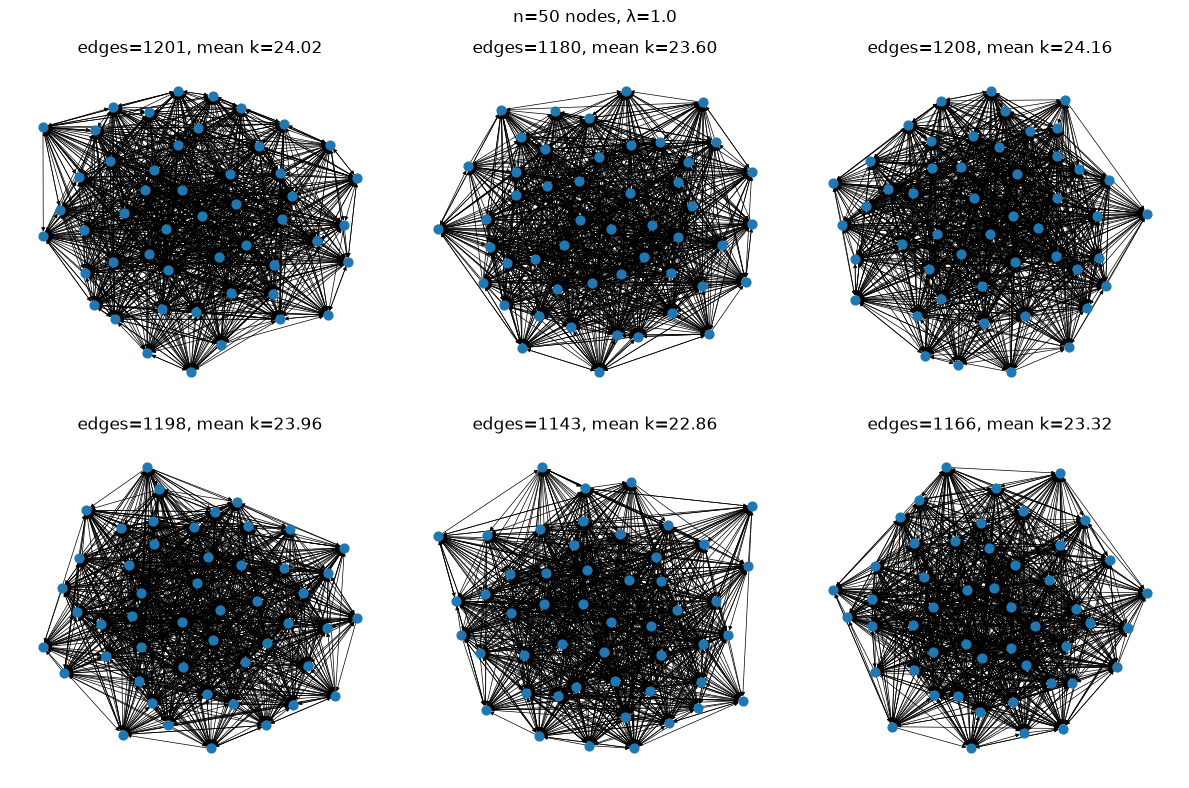

KeyboardInterrupt: 

In [2]:
import networkx as nx
import matplotlib.pyplot as plt


def visualize_samples(n_nodes, lam, n_samples=6, n_iter=20_000, seed=None, ncols=3):
    """Generate n_samples independent draws from DirectedGraphMCMC and plot them."""
    rng = np.random.default_rng(seed)
    nrows = int(np.ceil(n_samples / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for idx in range(n_samples):
        sampler = DirectedGraphMCMC(
            n_nodes=n_nodes, lam=lam, n_iter=n_iter,
            seed=rng.integers(1e9)
        )
        sampler.run(burn_in=3000)

        G = nx.from_numpy_array(sampler.S, create_using=nx.DiGraph)
        pos = nx.spring_layout(G, seed=0)
        ax = axes[idx]
        nx.draw(
            G, pos, ax=ax, node_size=40, arrowsize=6,
            width=0.5, with_labels=False
        )
        ax.set_title(f"edges={sampler.S.sum()}, mean k={sampler.out_degree.mean():.2f}")

    for ax in axes[n_samples:]:
        ax.axis("off")

    fig.suptitle(f"n={n_nodes} nodes, λ={lam}")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    visualize_samples(n_nodes=50, lam=1.0, n_samples=6, seed=0)
    visualize_samples(n_nodes=100, lam=1.0, n_samples=6, seed=0)

In [47]:
import numpy as np


class DirectedGraphMCMC:
    """Metropolis-Hastings sampler for
    p(S) ∝ exp(-lambda * sum_i log(k_i + 1)) * eta^(total_edges)
    over directed graphs (no self-loops), where k_i is out-degree of node i."""

    def __init__(self, n_nodes, lam, eta=1.0, n_iter=100_000, seed=None):
        self.n = n_nodes
        self.lam = lam
        self.eta = eta
        self.log_eta = np.log(eta)
        self.n_iter = n_iter
        self.rng = np.random.default_rng(seed)
        self.S = np.zeros((self.n, self.n), dtype=np.int8)
        self.out_degree = self.S.sum(axis=1)

    def _node_energy(self, k):
        return self.lam * np.log(k + 0.9) - self.log_eta * k

    def energy(self):
        return np.sum(self._node_energy(self.out_degree))

    def _propose_edge(self):
        i = self.rng.integers(self.n)
        j = self.rng.integers(self.n - 1)
        j = j if j < i else j + 1  # avoid self-loop, uniform over j != i
        return i, j

    def _delta_energy(self, i, j):
        k_i = self.out_degree[i]
        k_new = k_i - 1 if self.S[i, j] else k_i + 1
        return self._node_energy(k_new) - self._node_energy(k_i)

    def _flip(self, i, j):
        if self.S[i, j]:
            self.S[i, j] = 0
            self.out_degree[i] -= 1
        else:
            self.S[i, j] = 1
            self.out_degree[i] += 1

    def step(self):
        i, j = self._propose_edge()
        dE = self._delta_energy(i, j)
        if dE <= 0 or self.rng.random() < np.exp(-dE):
            self._flip(i, j)
            return True
        return False

    def run(self, burn_in=0, thin=1, collect=False):
        samples = [] if collect else None
        for t in range(self.n_iter):
            self.step()
            if collect and t >= burn_in and (t - burn_in) % thin == 0:
                samples.append(self.S.copy())
        return samples


if __name__ == "__main__":
    for n_nodes in [50, 100]:
        sampler = DirectedGraphMCMC(n_nodes=n_nodes, lam=1.0, eta=0.3, n_iter=50_000, seed=0)
        sampler.run(burn_in=3000)
        print(
            f"n={n_nodes}: energy={sampler.energy():.3f}, "
            f"mean out-degree={sampler.out_degree.mean():.3f}, "
            f"edges={sampler.S.sum()}"
        )

n=50: energy=764.126, mean out-degree=10.680, edges=534
n=100: energy=2992.455, mean out-degree=22.260, edges=2226


In [48]:
def visualize_samples(n_nodes, lam, eta=0.2, n_samples=6, n_iter=20_000, seed=None, ncols=3):
    rng = np.random.default_rng(seed)
    nrows = int(np.ceil(n_samples / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for idx in range(n_samples):
        sampler = DirectedGraphMCMC(
            n_nodes=n_nodes, lam=lam, eta=eta, n_iter=n_iter,
            seed=rng.integers(1e9)
        )
        sampler.run(1000)

        G = nx.from_numpy_array(sampler.S, create_using=nx.DiGraph)
        pos = nx.spring_layout(G, seed=0)
        ax = axes[idx]
        nx.draw(G, pos, ax=ax, node_size=40, arrowsize=6, width=0.5, with_labels=False)
        ax.set_title(f"edges={sampler.S.sum()}, mean k={sampler.out_degree.mean():.2f}")

    for ax in axes[n_samples:]:
        ax.axis("off")

    fig.suptitle(f"n={n_nodes} nodes, λ={lam}, η={eta}")
    plt.tight_layout()
    plt.show()

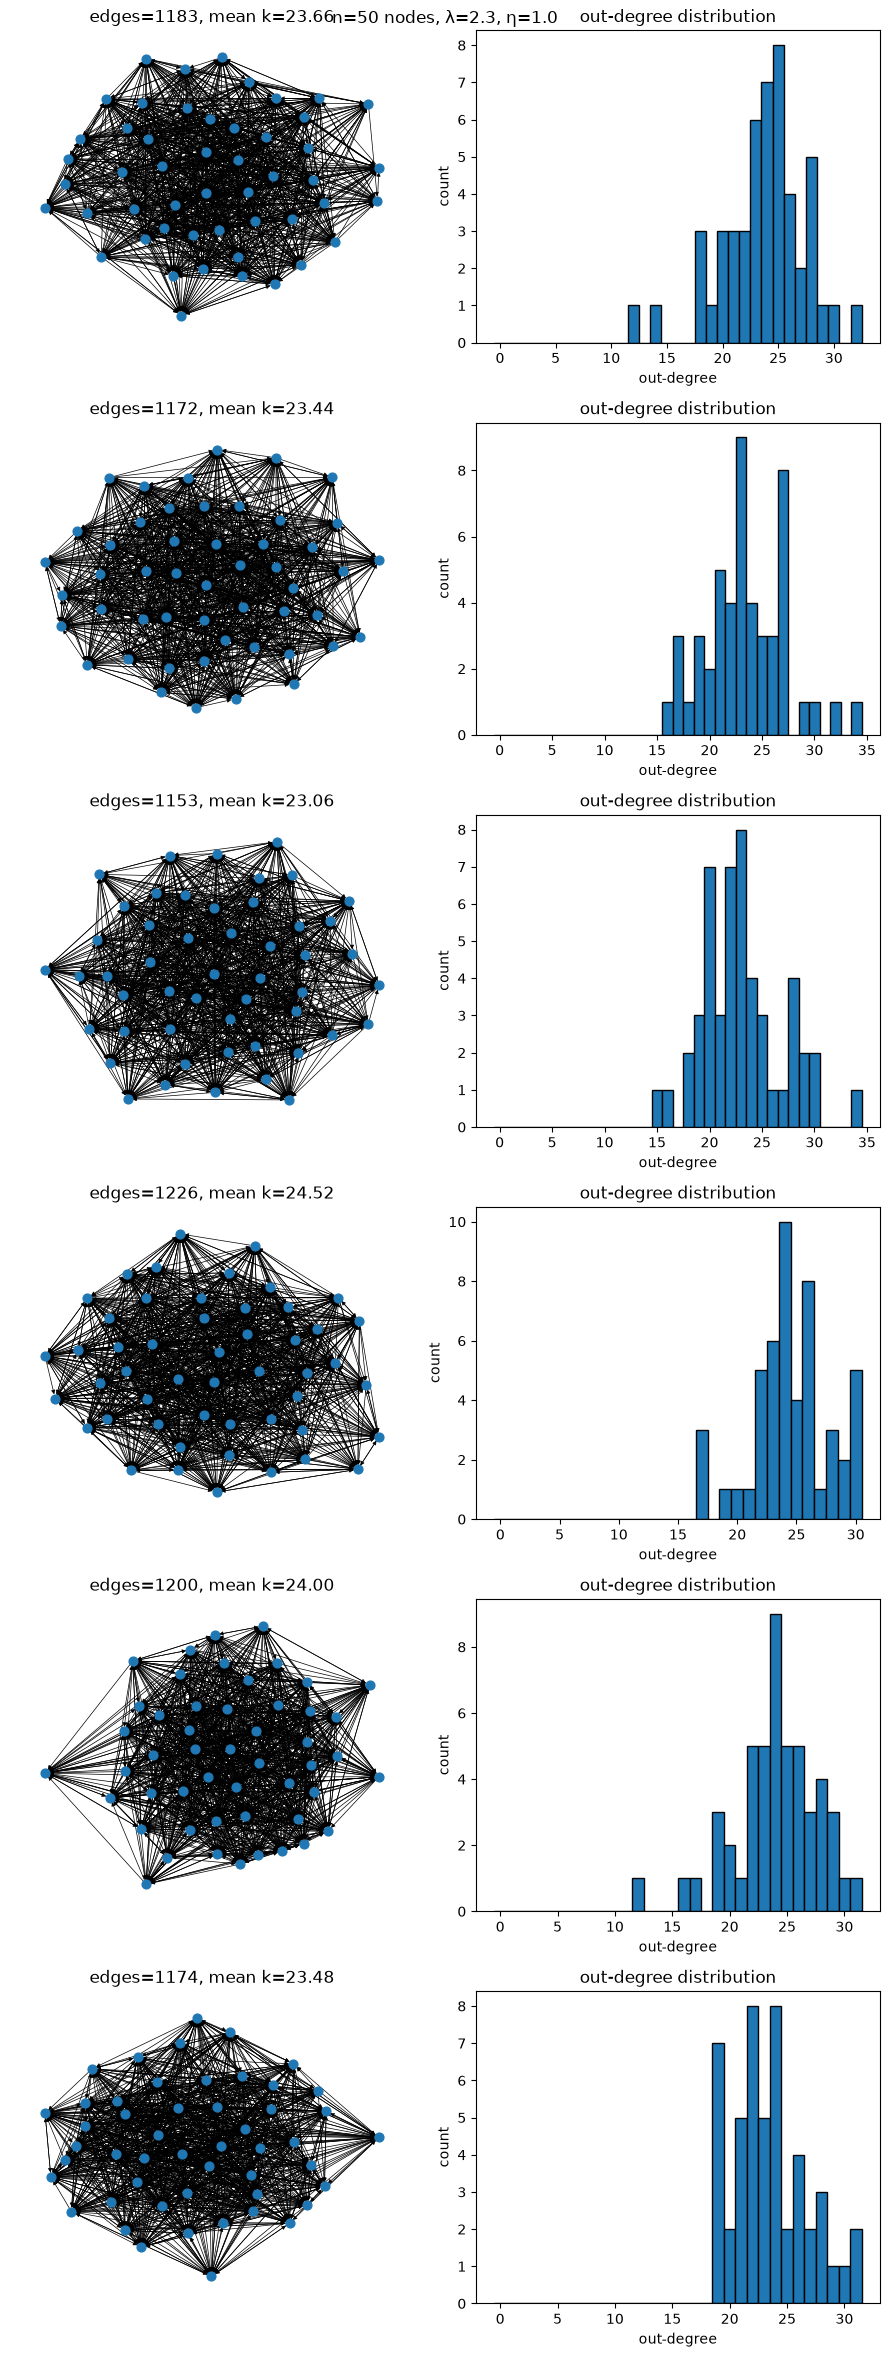

In [ ]:
visualize_samples(n_nodes=50, lam=2.3, eta=1.0, n_samples=6, seed=0)
visualize_samples(n_nodes=100, lam=1.0, n_samples=6, seed=0)

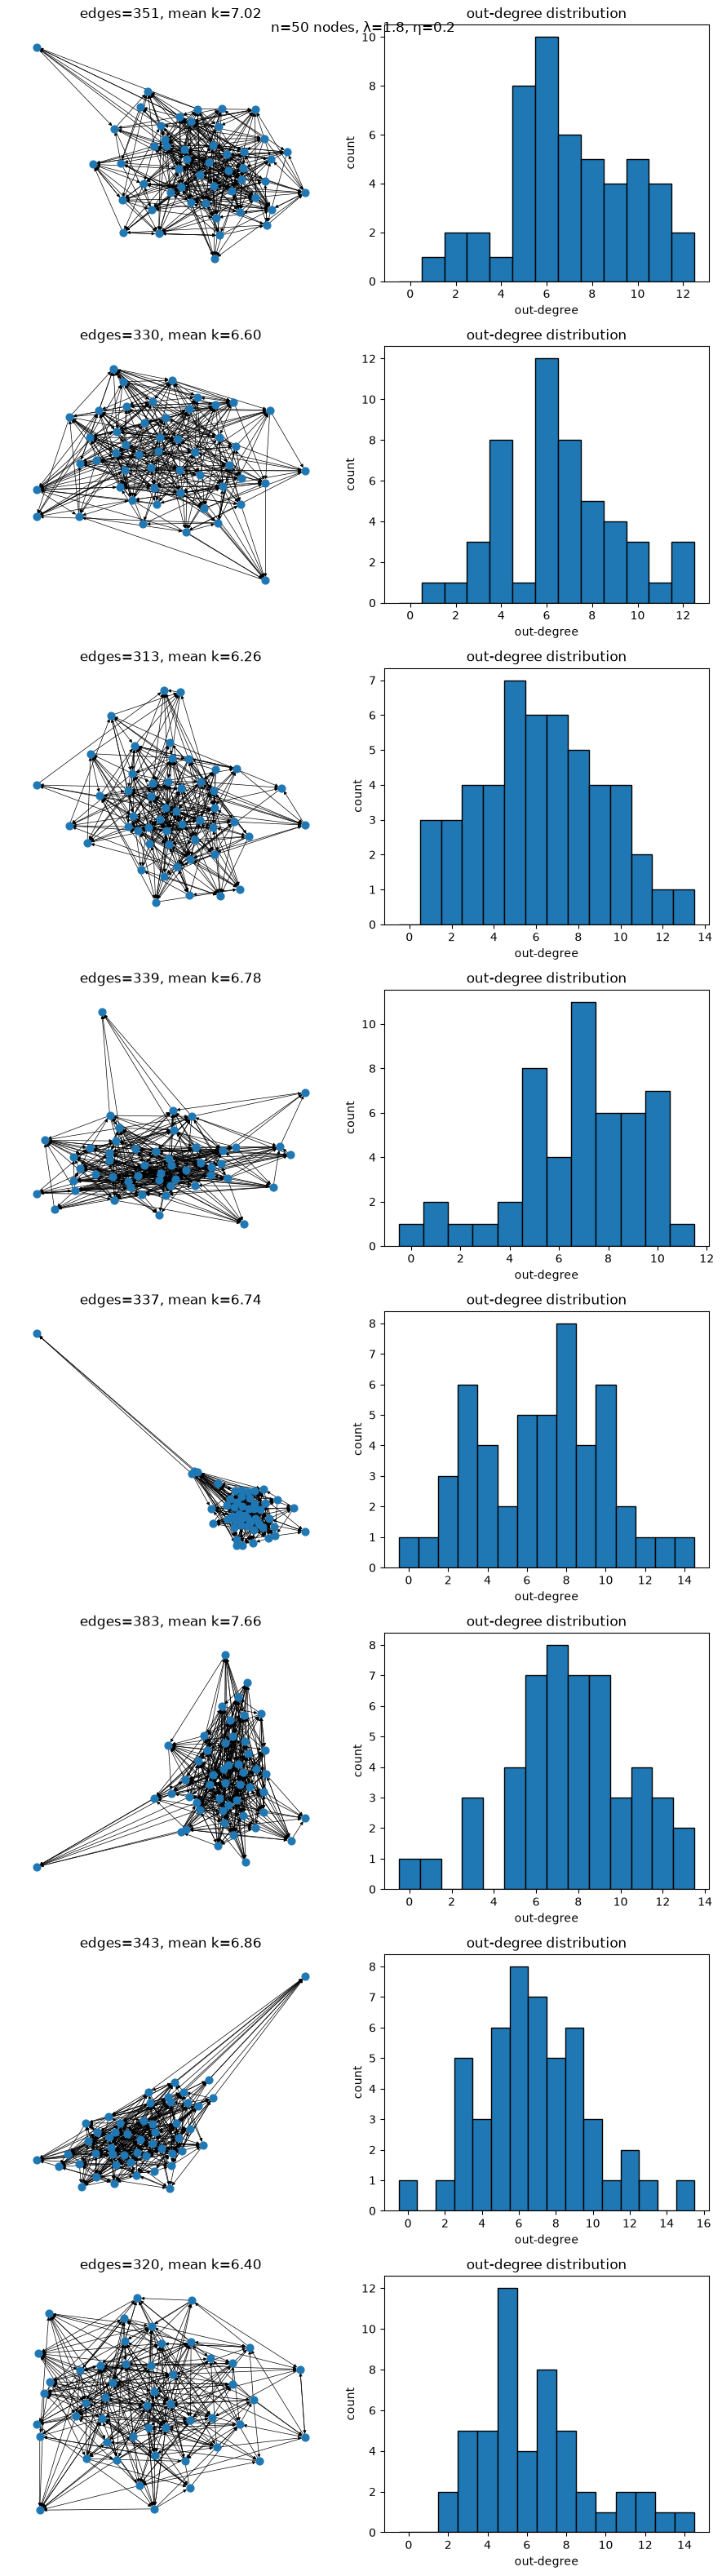

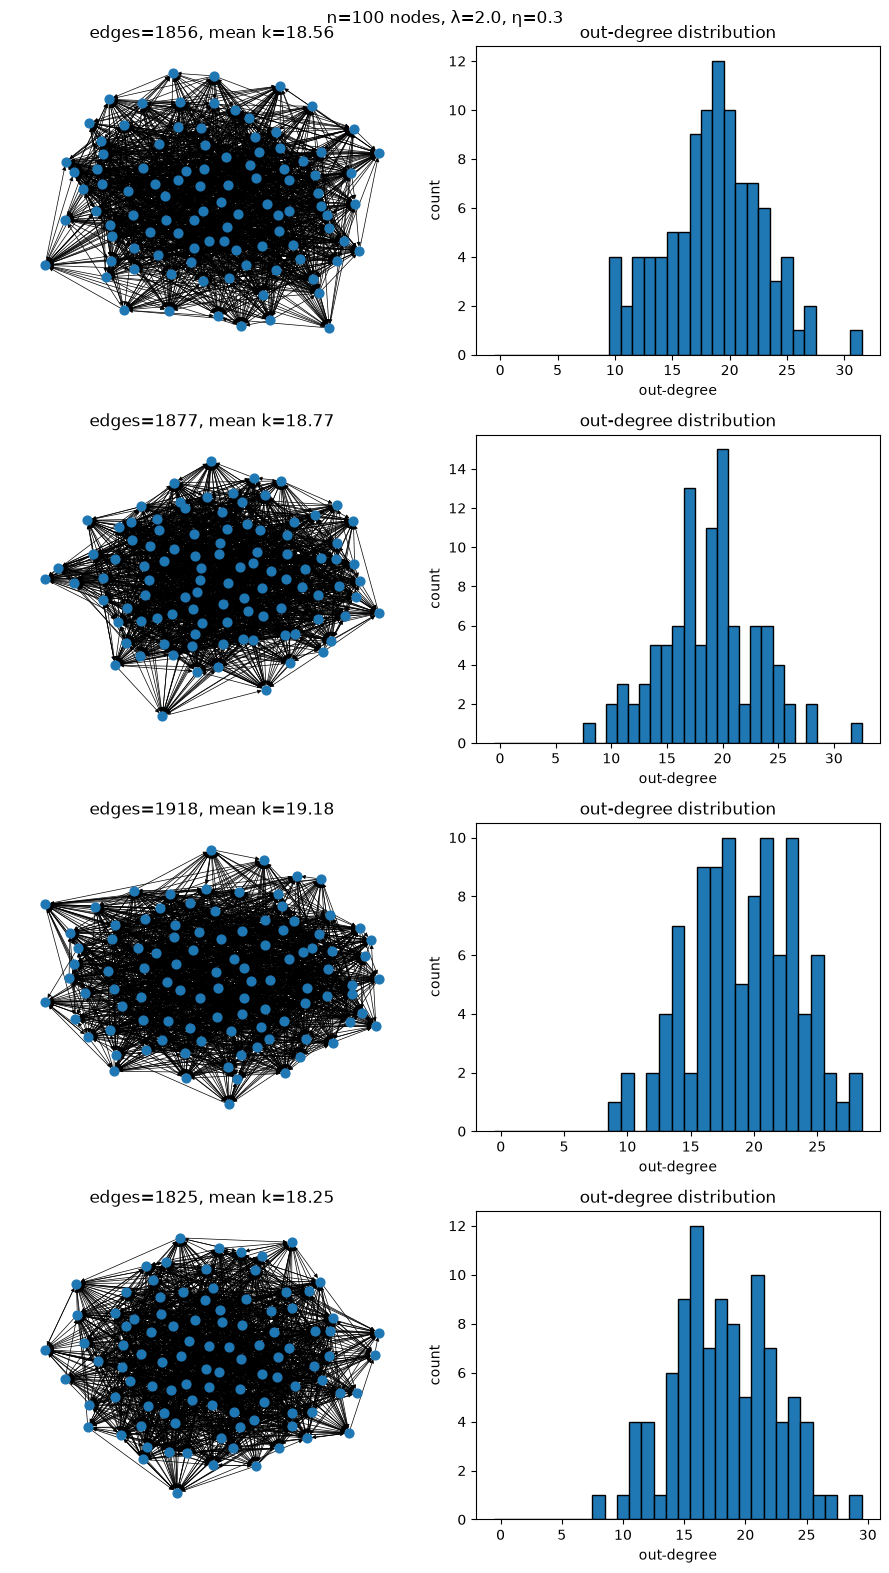

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def visualize_samples(n_nodes, lam, eta=1.0, n_samples=6, n_iter=20_000, seed=None):
    """Generate n_samples independent draws and plot each graph next to its
    out-degree distribution."""
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(n_samples, 2, figsize=(9, 4 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 2)

    for idx in range(n_samples):
        sampler = DirectedGraphMCMC(
            n_nodes=n_nodes, lam=lam, eta=eta, n_iter=n_iter,
            seed=rng.integers(1e9)
        )
        sampler.run(burn_in=3000)

        # graph panel
        ax_graph = axes[idx, 0]
        G = nx.from_numpy_array(sampler.S, create_using=nx.DiGraph)
        pos = nx.spring_layout(G, seed=0)
        nx.draw(G, pos, ax=ax_graph, node_size=40, arrowsize=6, width=0.5, with_labels=False)
        ax_graph.set_title(f"edges={sampler.S.sum()}, mean k={sampler.out_degree.mean():.2f}")

        # degree distribution panel
        ax_hist = axes[idx, 1]
        max_k = sampler.out_degree.max()
        bins = np.arange(0, max_k + 2) - 0.5
        ax_hist.hist(sampler.out_degree, bins=bins, edgecolor="black")
        ax_hist.set_xlabel("out-degree")
        ax_hist.set_ylabel("count")
        ax_hist.set_title("out-degree distribution")

    fig.suptitle(f"n={n_nodes} nodes, λ={lam}, η={eta}")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    visualize_samples(n_nodes=50, lam=1.8, eta=0.2, n_samples=8, seed=0)
    visualize_samples(n_nodes=100, lam=2.0, eta=0.3, n_samples=4, seed=0)

In [43]:
import numpy as np
from scipy.special import gammaln


class DirectedGraphMCMC:
    """Metropolis-Hastings sampler with target marginal out-degree distribution
    P(k) ∝ (k+eps)^(-lambda) * eta^k, achieved by cancelling the C(n-1,k)
    combinatorial multiplicity of edge-subset choices."""

    def __init__(self, n_nodes, lam, eta=1.0, eps=1.0, n_iter=100_000, seed=None):
        self.n = n_nodes
        self.lam = lam
        self.eta = eta
        self.eps = eps
        self.log_eta = np.log(eta)
        self.n_iter = n_iter
        self.rng = np.random.default_rng(seed)
        self.S = np.zeros((self.n, self.n), dtype=np.int8)
        self.out_degree = self.S.sum(axis=1)

        # precompute log C(n-1, k) for k = 0..n-1
        m = self.n - 1
        k = np.arange(m + 1)
        self._log_binom = gammaln(m + 1) - gammaln(k + 1) - gammaln(m - k + 1)

    def _node_energy(self, k):
        return self.lam * np.log(k + self.eps) - self.log_eta * k - self._log_binom[k]

    def energy(self):
        return np.sum(self._node_energy(self.out_degree))

    def _propose_edge(self):
        i = self.rng.integers(self.n)
        j = self.rng.integers(self.n - 1)
        j = j if j < i else j + 1
        return i, j

    def _delta_energy(self, i, j):
        k_i = self.out_degree[i]
        k_new = k_i - 1 if self.S[i, j] else k_i + 1
        return self._node_energy(k_new) - self._node_energy(k_i)

    def _flip(self, i, j):
        if self.S[i, j]:
            self.S[i, j] = 0
            self.out_degree[i] -= 1
        else:
            self.S[i, j] = 1
            self.out_degree[i] += 1

    def step(self):
        i, j = self._propose_edge()
        dE = self._delta_energy(i, j)
        if dE <= 0 or self.rng.random() < np.exp(-dE):
            self._flip(i, j)
            return True
        return False

    def run(self, burn_in=0, thin=1, collect=False):
        samples = [] if collect else None
        for t in range(self.n_iter):
            self.step()
            if collect and t >= burn_in and (t - burn_in) % thin == 0:
                samples.append(self.S.copy())
        return samples

In [44]:
def check_marginal(n_nodes, lam, eta, eps=1.0):
    k = np.arange(n_nodes)
    log_w = -lam * np.log(k + eps) + k * np.log(eta)
    w = np.exp(log_w - log_w.max())
    return k, w / w.sum()

k, p = check_marginal(50, lam=2.0, eta=1.0)  # eta=1 isolates the power-law part
print(np.round(p[:10], 4))

[0.6153 0.1538 0.0684 0.0385 0.0246 0.0171 0.0126 0.0096 0.0076 0.0062]


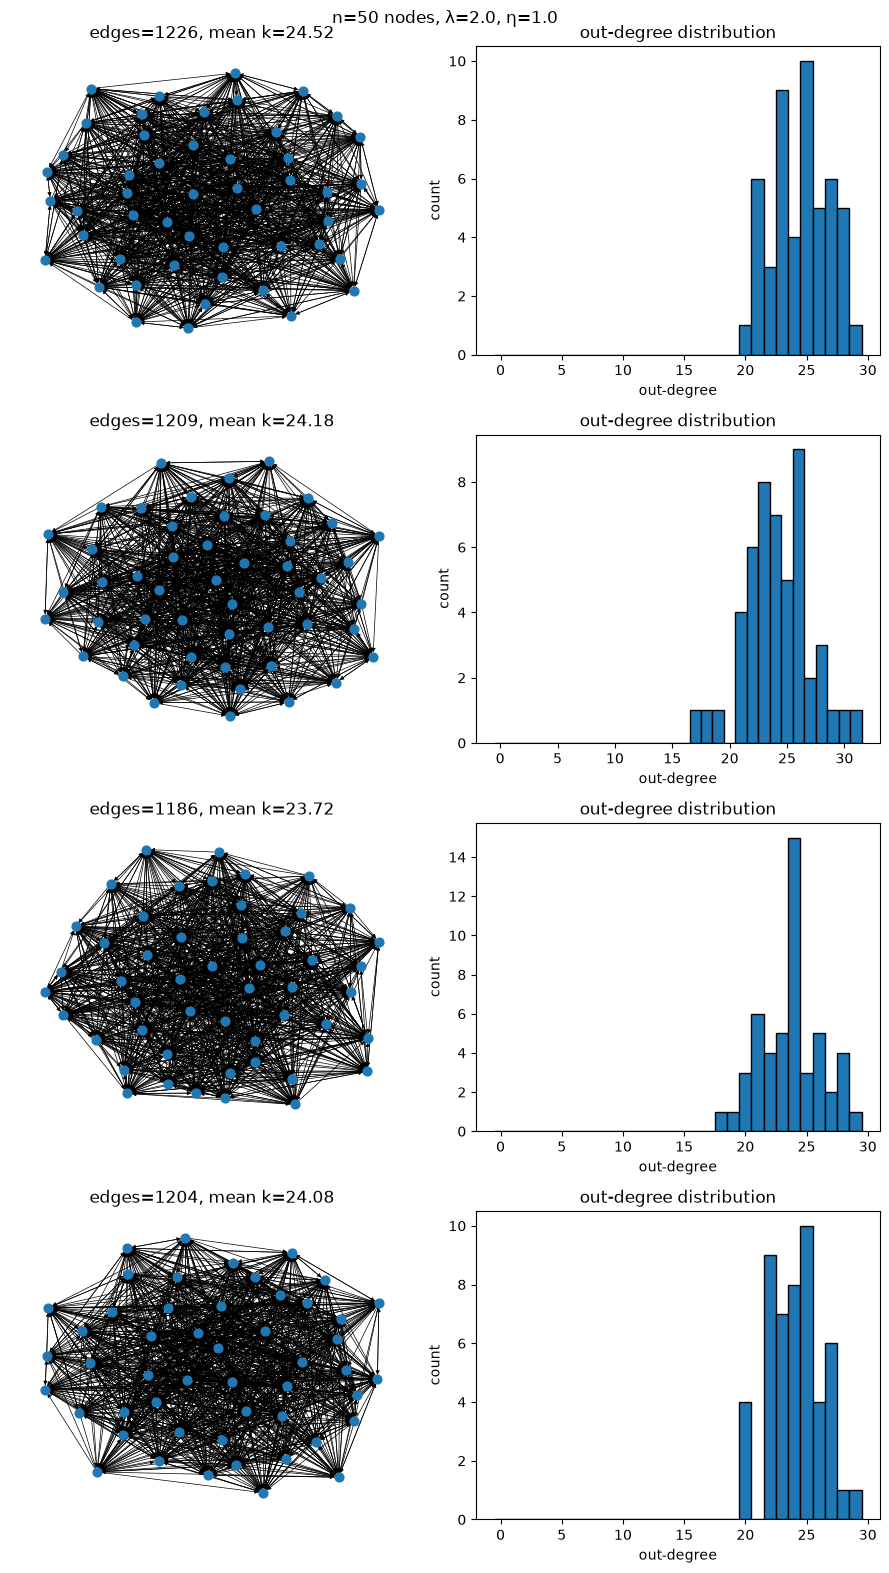

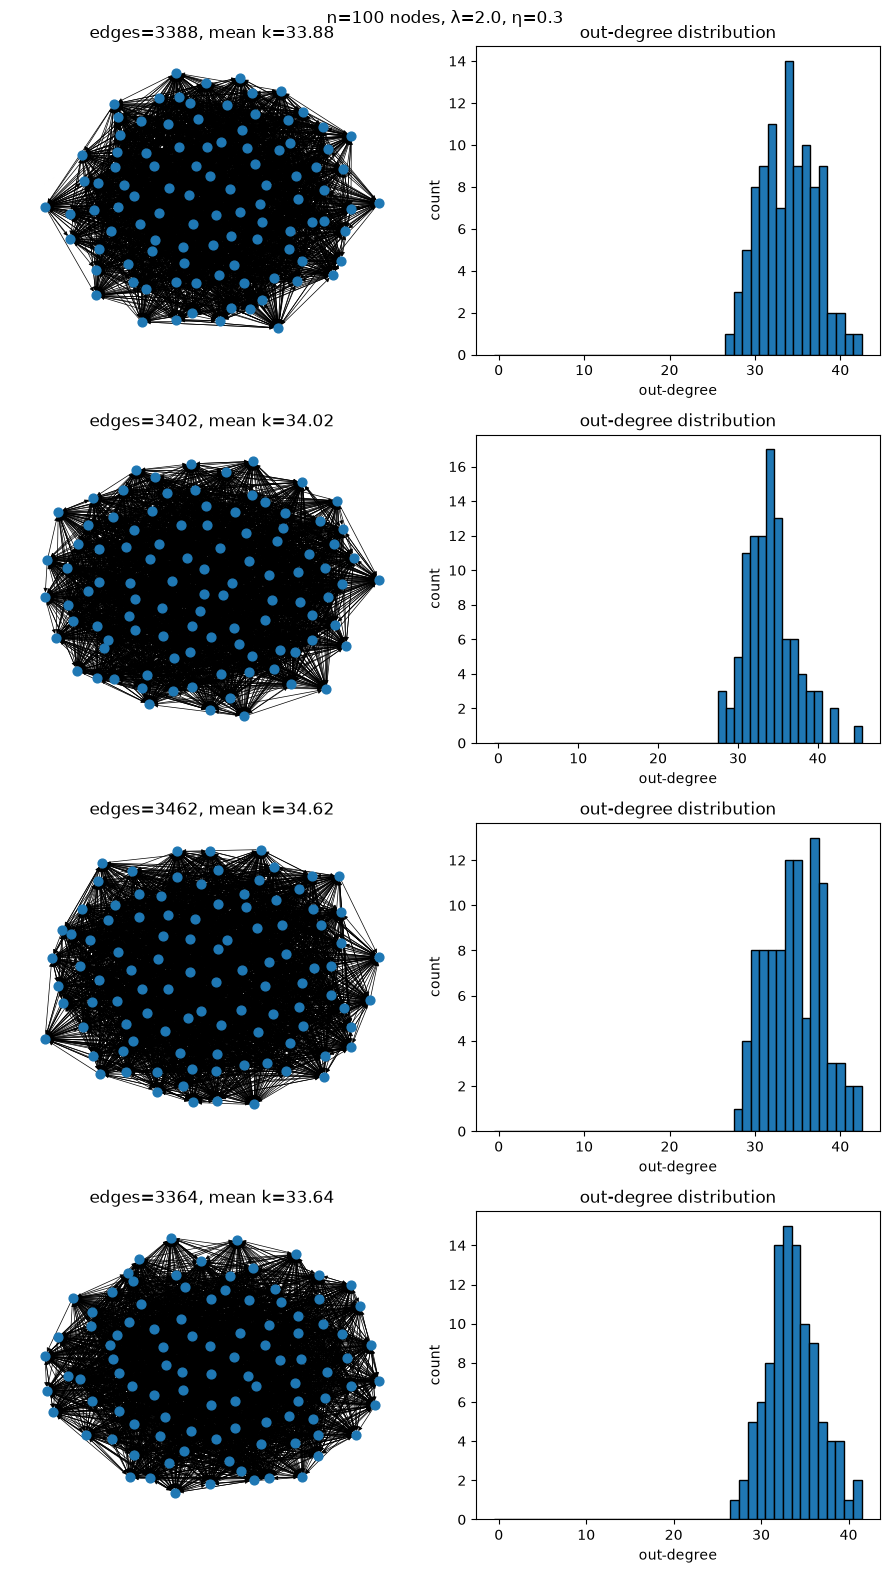

In [46]:
visualize_samples(n_nodes=50, lam=2.0, eta=1.0, n_samples=4, seed=0)
visualize_samples(n_nodes=100, lam=2.0, eta=0.3, n_samples=4, seed=0)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

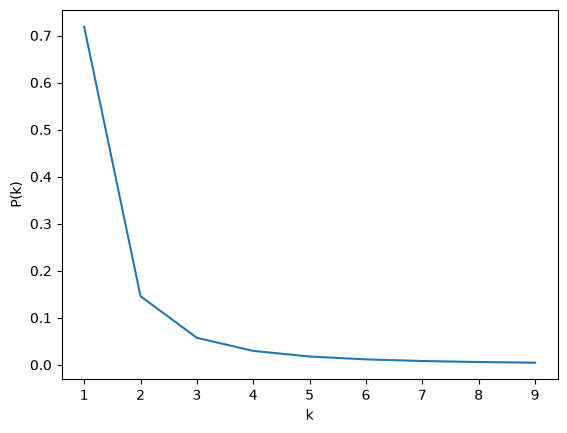

In [7]:
ks = np.arange(1, 10)
pks = np.power(ks, -2.3)
pks = pks / pks.sum()
plt.plot(ks, pks)
plt.ylabel("P(k)")
plt.xlabel("k")
plt.show()

In [8]:
N = 139
pks_N = np.floor(N * pks)
pks_N

array([99., 20.,  7.,  4.,  2.,  1.,  1.,  0.,  0.])

In [9]:
pks_N.sum()

np.float64(134.0)

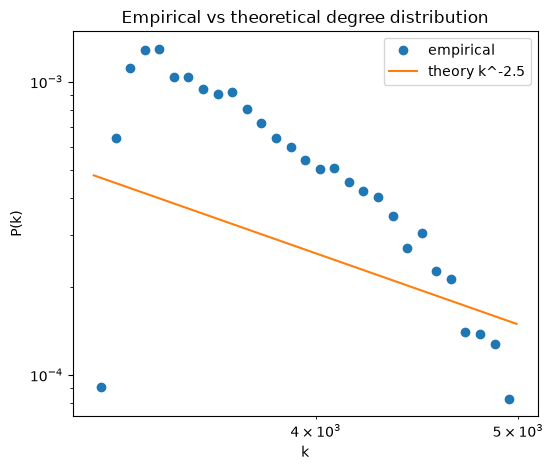

True gamma: 2.5, recovered gamma (MLE): 1.137


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
n = 5000          # number of vertices
gamma = 2.5        # target power-law exponent
x_min = 1.0         # minimum fitness
rng = np.random.default_rng(42)

# --- Step 1: draw fitness values from rho_x(x) ~ x^{-gamma}, x >= x_min ---
# Use inverse-CDF sampling. For P(x) = (gamma-1) x_min^(gamma-1) x^{-gamma},
# the CDF is F(x) = 1 - (x_min/x)^(gamma-1), so invert:
#   x = x_min * (1-u)^(-1/(gamma-1)),  u ~ Uniform(0,1)
u = rng.uniform(0, 1, n)
x = x_min * (1 - u) ** (-1 / (gamma - 1))

# --- Step 2: build edge probabilities p_ij = x_i x_j / (1 + x_i x_j) ---
# (this is the fermionic/exact form from Eq. 24 in the sparse limit,
#  more accurate than the linear Chung-Lu approx for large x_i x_j)
X = np.outer(x, x)
P = X / (1 + X)
np.fill_diagonal(P, 0)  # no self-loops

# --- Step 3: sample the adjacency matrix ---
rand_matrix = rng.uniform(0, 1, (n, n))
A = (rand_matrix < P).astype(int)
A = np.triu(A, 1)
A = A + A.T  # symmetrize

# --- Step 4: compute realized degrees ---
k = A.sum(axis=1)

# --- Step 5: check the empirical degree distribution against target gamma ---
# log-log histogram
k_nonzero = k[k > 0]
bins = np.logspace(np.log10(k_nonzero.min()), np.log10(k_nonzero.max()), 30)
hist, edges = np.histogram(k_nonzero, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])

plt.figure(figsize=(6,5))
plt.loglog(centers, hist, 'o', label='empirical')

# overlay theoretical power law for comparison
kk = np.linspace(k_nonzero.min(), k_nonzero.max(), 200)
theory = (gamma-1) * k_nonzero.min()**(gamma-1) * kk**(-gamma)
plt.loglog(kk, theory, '-', label=f'theory k^-{gamma}')

plt.xlabel('k'); plt.ylabel('P(k)')
plt.legend(); plt.title('Empirical vs theoretical degree distribution')
plt.show()

# --- Step 6: fit gamma back out via MLE (Clauset-Shalizi-Newman estimator) ---
k_min_fit = 3  # choose a reasonable cutoff, avoid small-k noise
tail = k[k >= k_min_fit]
gamma_hat = 1 + len(tail) / np.sum(np.log(tail / (k_min_fit - 0.5)))
print(f"True gamma: {gamma}, recovered gamma (MLE): {gamma_hat:.3f}")

mean degree: 3.04  max degree: 19


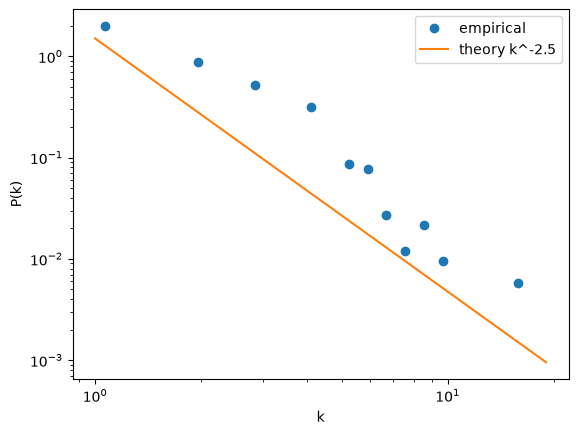

True gamma: 2.5, recovered gamma (MLE): 2.694


In [7]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
gamma = 2.5
avg_k_target = 5.0   # <-- target sparse average degree
rng = np.random.default_rng(250)

# corrected x_min derivation
x_min = (gamma - 2)/(gamma - 1) * np.sqrt(avg_k_target / (n - 1))

u = rng.uniform(0, 1, n)
x = x_min * (1 - u) ** (-1 / (gamma - 1))

X = np.outer(x, x)
P = X / (1 + X)
np.fill_diagonal(P, 0)

rand_matrix = rng.uniform(0, 1, (n, n))
A = (rand_matrix < P).astype(int)
A = np.triu(A, 1)
A = A + A.T

k = A.sum(axis=1)
print("mean degree:", k.mean(), " max degree:", k.max())

k_nonzero = k[k > 0]
bins = np.logspace(np.log10(k_nonzero.min()), np.log10(k_nonzero.max()), 25)
hist, edges = np.histogram(k_nonzero, bins=bins, density=True)
centers = np.sqrt(edges[:-1]*edges[1:])

plt.loglog(centers, hist, 'o', label='empirical')
kk = np.linspace(k_nonzero.min(), k_nonzero.max(), 200)
theory = (gamma-1)*k_nonzero.min()**(gamma-1)*kk**(-gamma)
plt.loglog(kk, theory, '-', label=f'theory k^-{gamma}')
plt.xlabel('k'); plt.ylabel('P(k)'); plt.legend()
plt.show()

k_min_fit = 3
tail = k[k >= k_min_fit]
gamma_hat = 1 + len(tail)/np.sum(np.log(tail/(k_min_fit-0.5)))
print(f"True gamma: {gamma}, recovered gamma (MLE): {gamma_hat:.3f}")

n=50: mean degree=3.60, max degree=15
n=100: mean degree=3.52, max degree=19
n=1000: mean degree=7.20, max degree=287


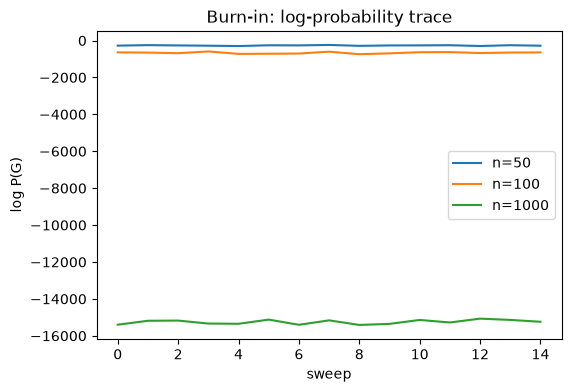

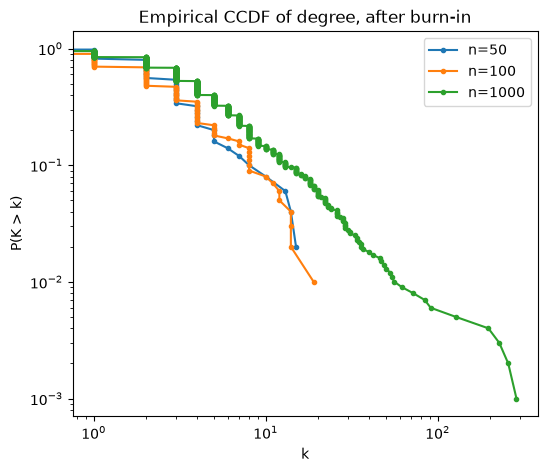

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def sample_fitness(n, gamma, avg_k_target, rng):
    x_min = (gamma - 2)/(gamma - 1) * np.sqrt(avg_k_target / (n - 1))
    u = rng.uniform(0, 1, n)
    x = x_min * (1 - u) ** (-1/(gamma - 1))
    return x

def build_p_matrix(x):
    X = np.outer(x, x)
    P = X / (1 + X)
    np.fill_diagonal(P, 0)
    return P

def log_prob(A, P, eps=1e-12):
    # log P(G) up to the (irrelevant, constant given x) normalization —
    # sum of sigma_ij*log(p_ij) + (1-sigma_ij)*log(1-p_ij) over i<j
    iu = np.triu_indices_from(A, k=1)
    p = P[iu]; s = A[iu]
    return np.sum(s*np.log(p+eps) + (1-s)*np.log(1-p+eps))

def gibbs_sampler(n, gamma, avg_k_target, n_sweeps, seed=0):
    rng = np.random.default_rng(seed)
    x = sample_fitness(n, gamma, avg_k_target, rng)
    P = build_p_matrix(x)

    # random initial graph (arbitrary start, to make burn-in visible)
    A = (rng.uniform(0,1,(n,n)) < 0.5).astype(int)
    A = np.triu(A,1); A = A + A.T

    iu = np.triu_indices(n, k=1)
    n_pairs = len(iu[0])
    logp_trace = []

    for sweep in range(n_sweeps):
        order = rng.permutation(n_pairs)
        for idx in order:
            i, j = iu[0][idx], iu[1][idx]
            # exact Gibbs update: resample this edge from its (here, exact
            # marginal) conditional probability p_ij
            A[i,j] = A[j,i] = 1 if rng.uniform() < P[i,j] else 0
        logp_trace.append(log_prob(A, P))

    return A, x, P, logp_trace

# --- Run for n = 50, 100, 1000 ---
results = {}
for n in [50, 100, 1000]:
    A, x, P, trace = gibbs_sampler(n, gamma=2.2, avg_k_target=15, n_sweeps=15, seed=1)
    results[n] = (A, x, P, trace)
    print(f"n={n}: mean degree={A.sum(1).mean():.2f}, max degree={A.sum(1).max()}")

# --- Plot burn-in traces ---
plt.figure(figsize=(6,4))
for n in [50, 100, 1000]:
    plt.plot(results[n][3], label=f'n={n}')
plt.xlabel('sweep'); plt.ylabel('log P(G)')
plt.legend(); plt.title('Burn-in: log-probability trace')
plt.show()

# --- Plot degree distributions (CCDF, more robust for small n) ---
plt.figure(figsize=(6,5))
for n in [50, 100, 1000]:
    A = results[n][0]
    k = A.sum(1)
    k_sorted = np.sort(k)[::-1]
    ccdf = np.arange(1, len(k_sorted)+1) / len(k_sorted)
    plt.loglog(k_sorted, ccdf, 'o-', label=f'n={n}', markersize=3)
plt.xlabel('k'); plt.ylabel('P(K > k)')
plt.legend(); plt.title('Empirical CCDF of degree, after burn-in')
plt.show()

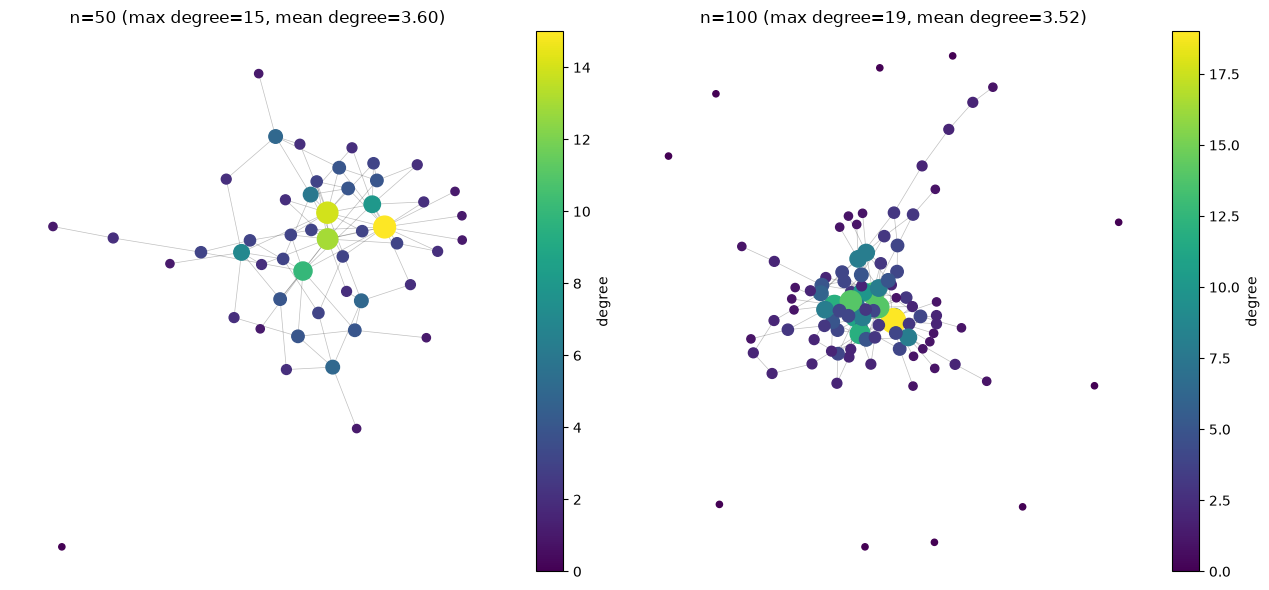

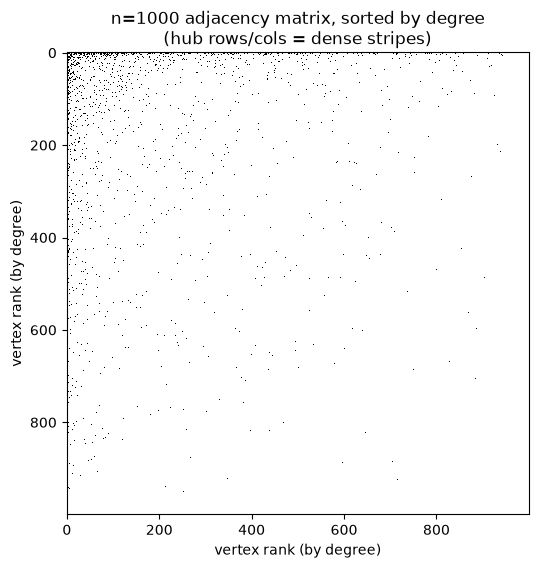

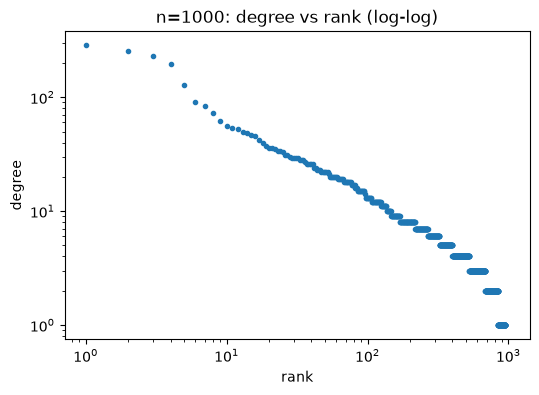

In [13]:
import networkx as nx

def visualize_graph(A, x, n, ax=None):
    G = nx.from_numpy_array(A)
    k = np.array([d for _, d in G.degree()])

    pos = nx.spring_layout(G, seed=1, k=1.5/np.sqrt(n))  # k spreads nodes out a bit

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    # node size/color by degree -- hubs should visibly stand out
    node_sizes = 20 + 15*k
    node_colors = k

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.5)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                                    node_color=node_colors, cmap='viridis')
    plt.colorbar(nodes, ax=ax, label='degree')
    ax.set_title(f'n={n} (max degree={k.max()}, mean degree={k.mean():.2f})')
    ax.axis('off')
    return G

# --- Visualize n=50 and n=100 as actual node-link graphs ---
fig, axes = plt.subplots(1, 2, figsize=(13,6))
visualize_graph(results[50][0], results[50][1], 50, ax=axes[0])
visualize_graph(results[100][0], results[100][1], 100, ax=axes[1])
plt.tight_layout()
plt.show()

# --- For n=1000: node-link plots are unreadable, use alternatives instead ---

# (a) Adjacency matrix heatmap, rows/cols sorted by degree (reveals hub structure)
A1000 = results[1000][0]
k1000 = A1000.sum(1)
order = np.argsort(-k1000)  # descending degree
A_sorted = A1000[np.ix_(order, order)]

plt.figure(figsize=(6,6))
plt.imshow(A_sorted, cmap='Greys', interpolation='none')
plt.title('n=1000 adjacency matrix, sorted by degree\n(hub rows/cols = dense stripes)')
plt.xlabel('vertex rank (by degree)'); plt.ylabel('vertex rank (by degree)')
plt.show()

# (b) Rank-degree plot -- shows the hub dominance directly
plt.figure(figsize=(6,4))
plt.loglog(np.arange(1, n+1), np.sort(k1000)[::-1], 'o', markersize=3)
plt.xlabel('rank'); plt.ylabel('degree')
plt.title('n=1000: degree vs rank (log-log)')
plt.show()

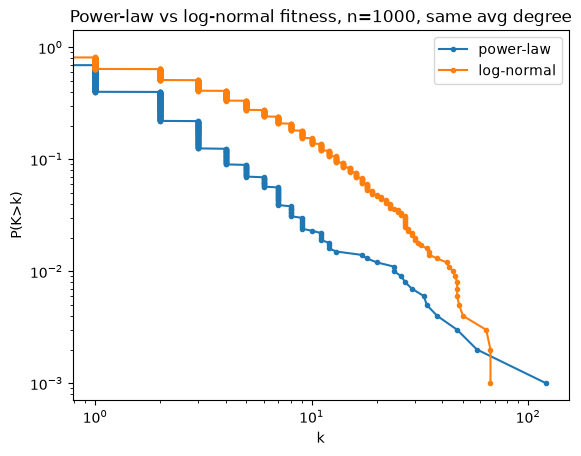

In [14]:
def sample_fitness_lognormal(n, mu, sigma, avg_k_target, rng):
    # solve for the shift so that E[k] matches avg_k_target
    # E[x] for lognormal(mu_x, sigma) is exp(mu_x + sigma^2/2)
    # we want (n-1)*E[x]^2 = avg_k_target  (same c = (n-1)*E[x] logic as before)
    # => E[x] = sqrt(avg_k_target/(n-1))
    Ex_target = np.sqrt(avg_k_target / (n - 1))
    mu_x = np.log(Ex_target) - sigma**2 / 2   # invert lognormal mean formula
    x = rng.lognormal(mean=mu_x, sigma=sigma, size=n)
    return x

# --- compare power-law vs log-normal fitness, same n and same avg degree ---
n = 1000
avg_k_target = 5
rng = np.random.default_rng(7)

x_pl = sample_fitness(n, gamma=2.2, avg_k_target=avg_k_target, rng=rng)
x_ln = sample_fitness_lognormal(n, mu=0, sigma=1.2, avg_k_target=avg_k_target, rng=rng)

for name, x in [('power-law', x_pl), ('log-normal', x_ln)]:
    P = build_p_matrix(x)
    rand_matrix = rng.uniform(0,1,(n,n))
    A = (rand_matrix < P).astype(int)
    A = np.triu(A,1); A = A + A.T
    k = A.sum(1)
    k_sorted = np.sort(k)[::-1]
    ccdf = np.arange(1,len(k_sorted)+1)/len(k_sorted)
    plt.loglog(k_sorted, ccdf, 'o-', markersize=3, label=name)

plt.xlabel('k'); plt.ylabel('P(K>k)')
plt.legend(); plt.title(f'Power-law vs log-normal fitness, n={n}, same avg degree')
plt.show()

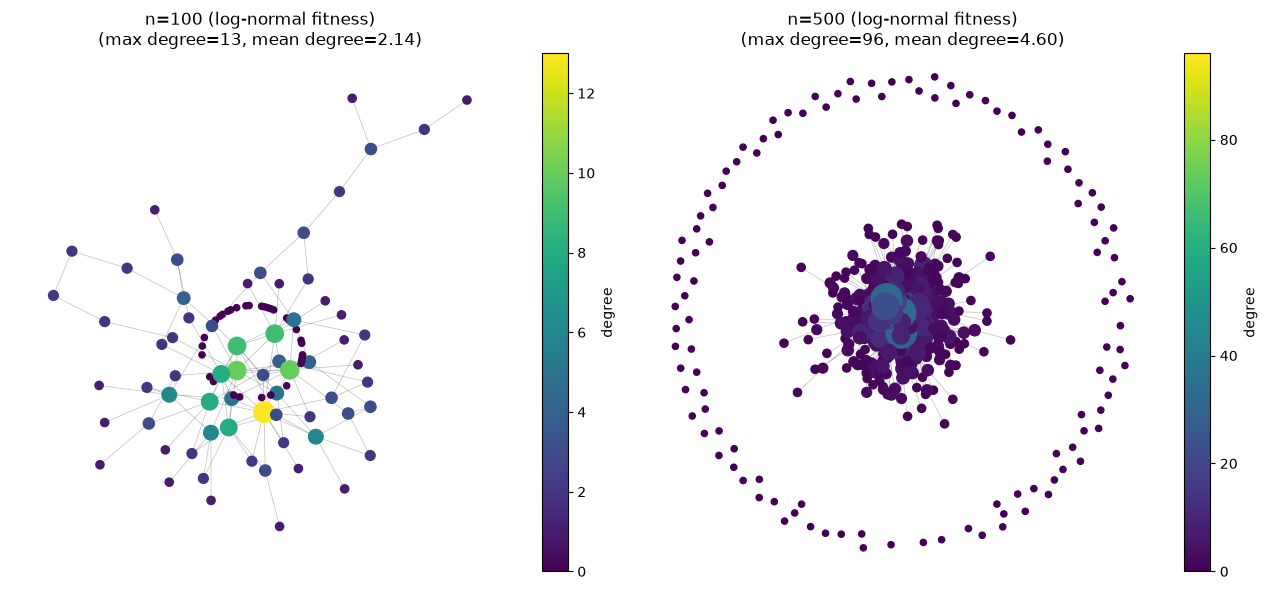

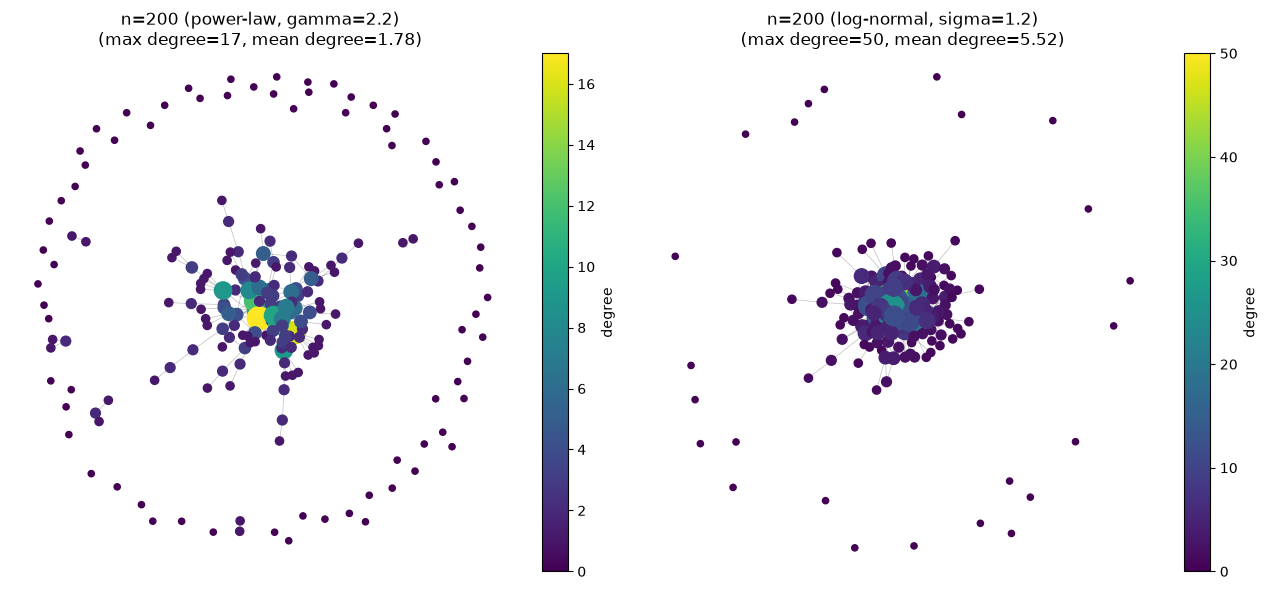

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def sample_fitness_lognormal(n, mu_target_shift, sigma, avg_k_target, rng):
    Ex_target = np.sqrt(avg_k_target / (n - 1))
    mu_x = np.log(Ex_target) - sigma**2 / 2
    x = rng.lognormal(mean=mu_x, sigma=sigma, size=n)
    return x

def build_p_matrix(x):
    X = np.outer(x, x)
    P = X / (1 + X)
    np.fill_diagonal(P, 0)
    return P

def sample_graph_from_fitness(x, rng):
    n = len(x)
    P = build_p_matrix(x)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < P).astype(int)
    A = np.triu(A, 1)
    A = A + A.T
    return A

def visualize_graph(A, n, title_extra='', ax=None, layout='spring'):
    G = nx.from_numpy_array(A)
    k = np.array([d for _, d in G.degree()])

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=1, k=1.5/np.sqrt(n))
    else:
        pos = nx.kamada_kawai_layout(G)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    node_sizes = 20 + 15*k
    node_colors = k

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.5)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                                    node_color=node_colors, cmap='viridis')
    plt.colorbar(nodes, ax=ax, label='degree')
    ax.set_title(f'n={n}{title_extra}\n(max degree={k.max()}, mean degree={k.mean():.2f})')
    ax.axis('off')
    return G, k

# --- Generate log-normal-fitness graphs at n=100 and n=500 ---
rng = np.random.default_rng(7)
sigma = 1.2
avg_k_target = 5

fig, axes = plt.subplots(1, 2, figsize=(13,6))

for ax, n in zip(axes, [100, 500]):
    x = sample_fitness_lognormal(n, mu_target_shift=0, sigma=sigma,
                                  avg_k_target=avg_k_target, rng=rng)
    A = sample_graph_from_fitness(x, rng)
    visualize_graph(A, n, title_extra=' (log-normal fitness)', ax=ax,
                     layout='kamada_kawai' if n <= 100 else 'spring')

plt.tight_layout()
plt.show()

# --- Side-by-side comparison: power-law vs log-normal at the same n ---
def sample_fitness_powerlaw(n, gamma, avg_k_target, rng):
    x_min = (gamma - 2)/(gamma - 1) * np.sqrt(avg_k_target / (n - 1))
    u = rng.uniform(0, 1, n)
    x = x_min * (1 - u) ** (-1/(gamma - 1))
    return x

fig, axes = plt.subplots(1, 2, figsize=(13,6))
n_compare = 200

x_pl = sample_fitness_powerlaw(n_compare, gamma=2.2, avg_k_target=5, rng=rng)
A_pl = sample_graph_from_fitness(x_pl, rng)
visualize_graph(A_pl, n_compare, title_extra=' (power-law, gamma=2.2)', ax=axes[0])

x_ln = sample_fitness_lognormal(n_compare, mu_target_shift=0, sigma=1.2,
                                 avg_k_target=5, rng=rng)
A_ln = sample_graph_from_fitness(x_ln, rng)
visualize_graph(A_ln, n_compare, title_extra=' (log-normal, sigma=1.2)', ax=axes[1])

plt.tight_layout()
plt.show()

out-degree: mean 3.915 max 1009
in-degree:  mean 3.915 max 12


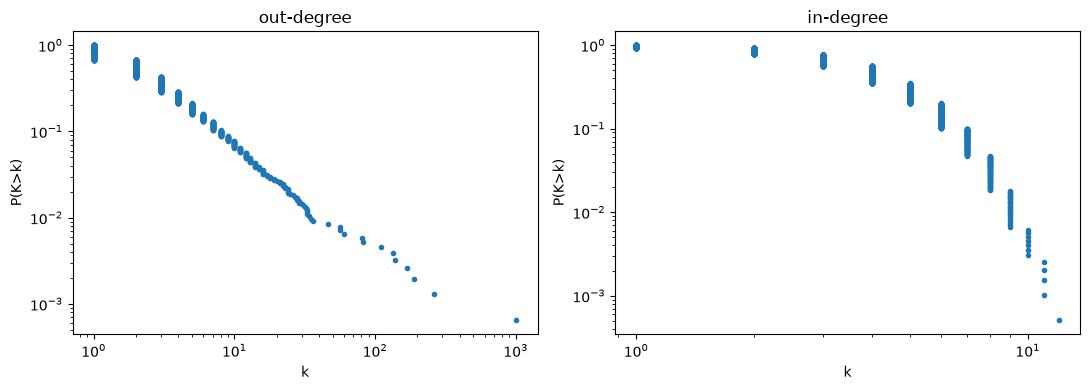

In [19]:
def sample_directed_fitness(n, gamma_out, avg_kout_target, rng, in_mode='uniform'):
    # out-fitness: power law with exponent gamma_out
    x_min = (gamma_out - 2)/(gamma_out - 1) * np.sqrt(avg_kout_target / (n - 1))
    u = rng.uniform(0, 1, n)
    x_out = x_min * (1 - u) ** (-1/(gamma_out - 1))

    # in-fitness: homogeneous (no imposed shape) -> Poisson-like in-degree
    if in_mode == 'uniform':
        x_in = np.full(n, np.sqrt(avg_kout_target / (n - 1)))  # matches avg in ~ avg out
    return x_out, x_in

def build_directed_p_matrix(x_out, x_in):
    # p[i,j] = P(edge from j -> i) = x_out[j] * x_in[i]  (sparse-limit approx)
    P = np.outer(x_in, x_out)   # P[i,j] uses x_in[i], x_out[j]
    np.fill_diagonal(P, 0)
    P = np.clip(P, 0, 1)  # guard against x_out*x_in > 1 in dense corners
    return P

def sample_directed_graph(x_out, x_in, rng):
    n = len(x_out)
    P = build_directed_p_matrix(x_out, x_in)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < P).astype(int)
    np.fill_diagonal(A, 0)
    return A  # A[i,j] = 1 means edge j -> i

# --- test: check out-degree follows power law, in-degree does not ---
n = 2000
rng = np.random.default_rng(3)
x_out, x_in = sample_directed_fitness(n, gamma_out=2.2, avg_kout_target=5, rng=rng)
A = sample_directed_graph(x_out, x_in, rng)

k_out = A.sum(axis=0)  # column sums = out-degree of each source vertex j
k_in  = A.sum(axis=1)  # row sums = in-degree of each target vertex i

print("out-degree: mean", k_out.mean(), "max", k_out.max())
print("in-degree:  mean", k_in.mean(),  "max", k_in.max())

fig, ax = plt.subplots(1,2, figsize=(11,4))
for data, name, axis in [(k_out,'out-degree',ax[0]), (k_in,'in-degree',ax[1])]:
    ks = np.sort(data[data>0])[::-1]
    ccdf = np.arange(1,len(ks)+1)/len(ks)
    axis.loglog(ks, ccdf, 'o', markersize=3)
    axis.set_title(name); axis.set_xlabel('k'); axis.set_ylabel('P(K>k)')
plt.tight_layout(); plt.show()

n=50: out-degree mean=1.10, max=9 | in-degree mean=1.10, max=4
n=100: out-degree mean=1.39, max=35 | in-degree mean=1.39, max=5
n=500: out-degree mean=1.53, max=35 | in-degree mean=1.53, max=7
n=2000: out-degree mean=1.68, max=213 | in-degree mean=1.68, max=6


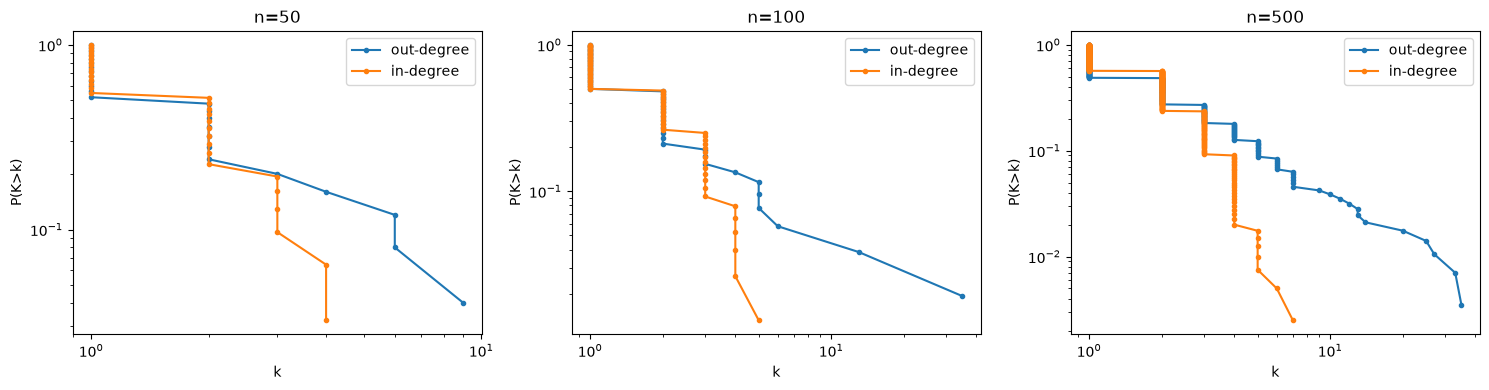

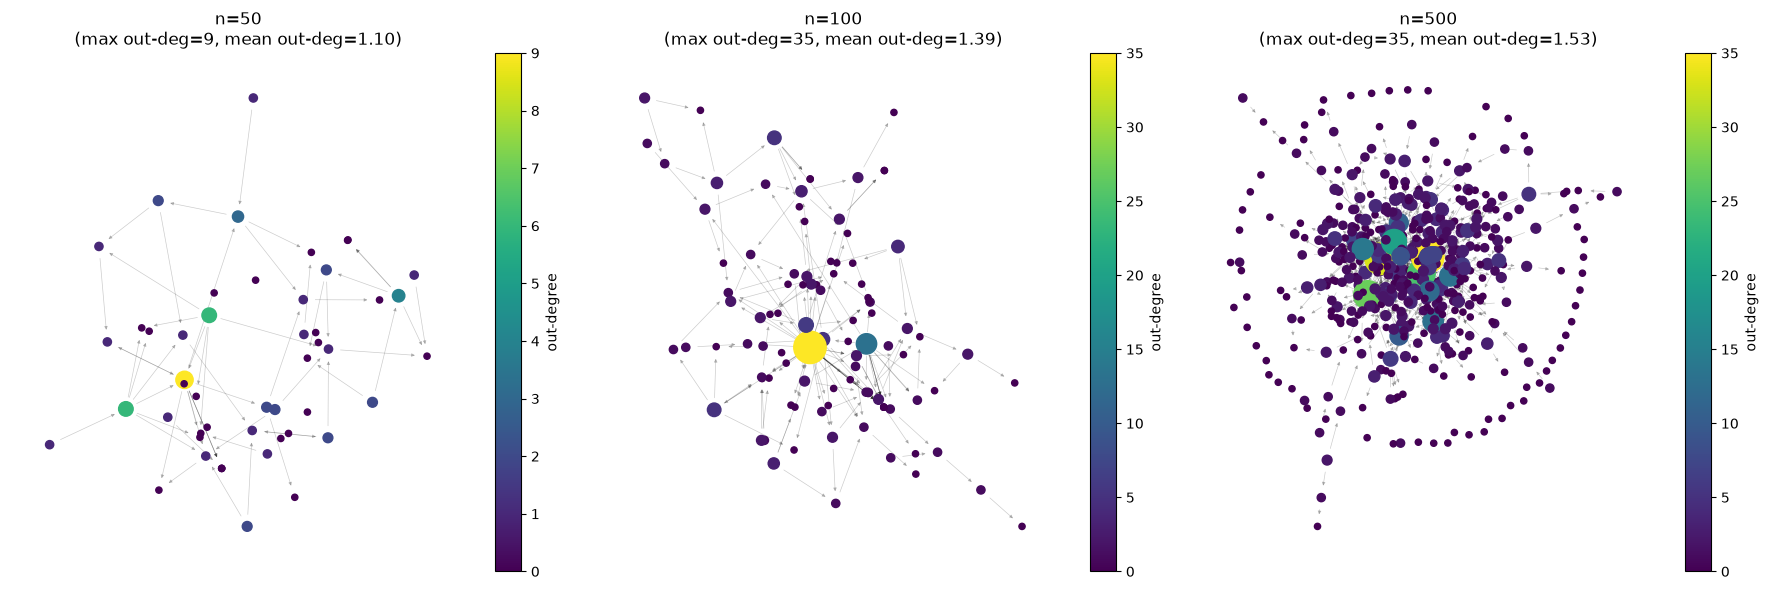

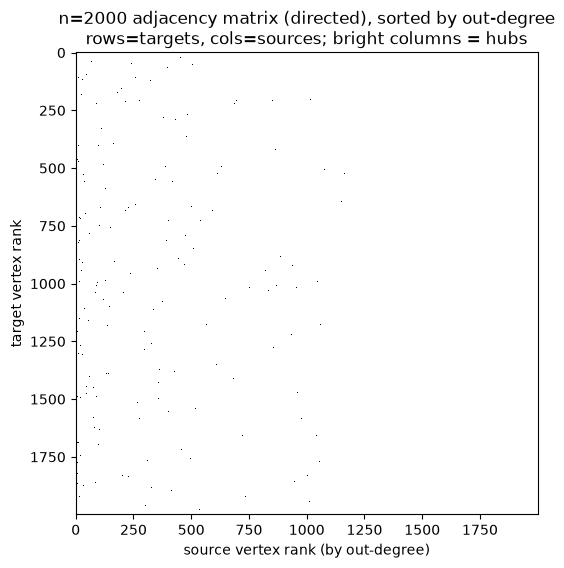

In [27]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1. Fitness sampling
# ============================================================

def sample_fitness_out_powerlaw(n, gamma_out, avg_kout_target, rng):
    """Power-law out-fitness, calibrated so mean out-degree ~= avg_kout_target."""
    x_min = (gamma_out - 2)/(gamma_out - 1) * np.sqrt(avg_kout_target / (n - 1))
    u = rng.uniform(0, 1, n)
    x_out = x_min * (1 - u) ** (-1/(gamma_out - 1))
    return x_out, x_min

def sample_fitness_in_homogeneous(n, x_min):
    """In-fitness: same scale (x_min) as out-fitness floor, not the naive sqrt formula.
    This is the fix from the previous step -- avoids accidental condensation."""
    return np.full(n, x_min)

# ============================================================
# 2. Exact edge probabilities (fermionic form, always in [0,1])
# ============================================================

def build_directed_p_matrix_exact(x_in, x_out):
    """P[i,j] = P(edge j -> i) = x_in[i]*x_out[j] / (1 + x_in[i]*x_out[j])"""
    prod = np.outer(x_in, x_out)
    P = prod / (1 + prod)
    np.fill_diagonal(P, 0)
    return P

def sample_directed_graph(x_in, x_out, rng):
    n = len(x_out)
    P = build_directed_p_matrix_exact(x_in, x_out)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < P).astype(int)
    np.fill_diagonal(A, 0)
    return A  # A[i,j] = 1 means edge j -> i

# ============================================================
# 3. Full pipeline for one n
# ============================================================

def run_directed_model(n, gamma_out, avg_kout_target, seed):
    rng = np.random.default_rng(seed)
    x_out, x_min = sample_fitness_out_powerlaw(n, gamma_out, avg_kout_target, rng)
    x_in = sample_fitness_in_homogeneous(n, x_min)
    A = sample_directed_graph(x_in, x_out, rng)

    k_out = A.sum(axis=0)  # column sums = out-degree
    k_in  = A.sum(axis=1)  # row sums  = in-degree

    print(f"n={n}: out-degree mean={k_out.mean():.2f}, max={k_out.max()} | "
          f"in-degree mean={k_in.mean():.2f}, max={k_in.max()}")

    return A, x_out, x_in, k_out, k_in

# ============================================================
# 4. CCDF comparison plot
# ============================================================

def plot_ccdfs(k_out, k_in, n, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    for data, name in [(k_out, 'out-degree'), (k_in, 'in-degree')]:
        ks = np.sort(data[data > 0])[::-1]
        ccdf = np.arange(1, len(ks)+1) / len(ks)
        ax.loglog(ks, ccdf, 'o-', markersize=3, label=name)
    ax.set_xlabel('k'); ax.set_ylabel('P(K>k)')
    ax.set_title(f'n={n}'); ax.legend()

# ============================================================
# 5. Graph visualization (node-link, colored/sized by out-degree)
# ============================================================

def visualize_directed_graph(A, n, title_extra='', ax=None, layout='spring'):
    G = nx.from_numpy_array(A, create_using=nx.DiGraph)
    # networkx DiGraph from array: A[i,j]=1 -> edge j->i in our convention,
    # but from_numpy_array treats A[i,j]=1 as edge i->j, so transpose first.
    G = nx.from_numpy_array(A.T, create_using=nx.DiGraph)

    k_out = np.array([d for _, d in G.out_degree()])

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=1, k=1.5/np.sqrt(n))
    else:
        pos = nx.kamada_kawai_layout(G)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    node_sizes = 20 + 15*k_out
    node_colors = k_out

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5,
                            arrowsize=5, arrowstyle='-|>')
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                                    node_color=node_colors, cmap='viridis')
    plt.colorbar(nodes, ax=ax, label='out-degree')
    ax.set_title(f'n={n}{title_extra}\n(max out-deg={k_out.max()}, mean out-deg={k_out.mean():.2f})')
    ax.axis('off')
    return G

# ============================================================
# 6. Run everything: n = 100, 500, 2000
# ============================================================

gamma_out = 2.2
avg_kout_target = 15
results = {}

for n, seed in [(50, 42),(100, 11), (500, 12), (2000, 13)]:
    A, x_out, x_in, k_out, k_in = run_directed_model(n, gamma_out, avg_kout_target, seed)
    results[n] = dict(A=A, x_out=x_out, x_in=x_in, k_out=k_out, k_in=k_in)

# --- CCDFs side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, n in zip(axes, [50, 100, 500, 2000]):
    plot_ccdfs(results[n]['k_out'], results[n]['k_in'], n, ax=ax)
plt.tight_layout(); plt.show()

# --- Graph visualizations: n=100 and n=500 (n=2000 would be unreadable) ---
fig, axes = plt.subplots(1, 3, figsize=(18,6))
visualize_directed_graph(results[50]['A'], 50, ax=axes[0], layout='kamada_kawai')
visualize_directed_graph(results[100]['A'], 100, ax=axes[1], layout='kamada_kawai')
visualize_directed_graph(results[500]['A'], 500, ax=axes[2], layout='spring')
plt.tight_layout(); plt.show()

# --- n=2000: adjacency heatmap sorted by out-degree instead of node-link plot ---
A2000 = results[2000]['A']
k_out_2000 = A2000.sum(axis=0)
order = np.argsort(-k_out_2000)
A_sorted = A2000[np.ix_(order, order)]

plt.figure(figsize=(6,6))
plt.imshow(A_sorted, cmap='Greys', interpolation='none')
plt.title('n=2000 adjacency matrix (directed), sorted by out-degree\n'
          'rows=targets, cols=sources; bright columns = hubs')
plt.xlabel('source vertex rank (by out-degree)')
plt.ylabel('target vertex rank')
plt.show()

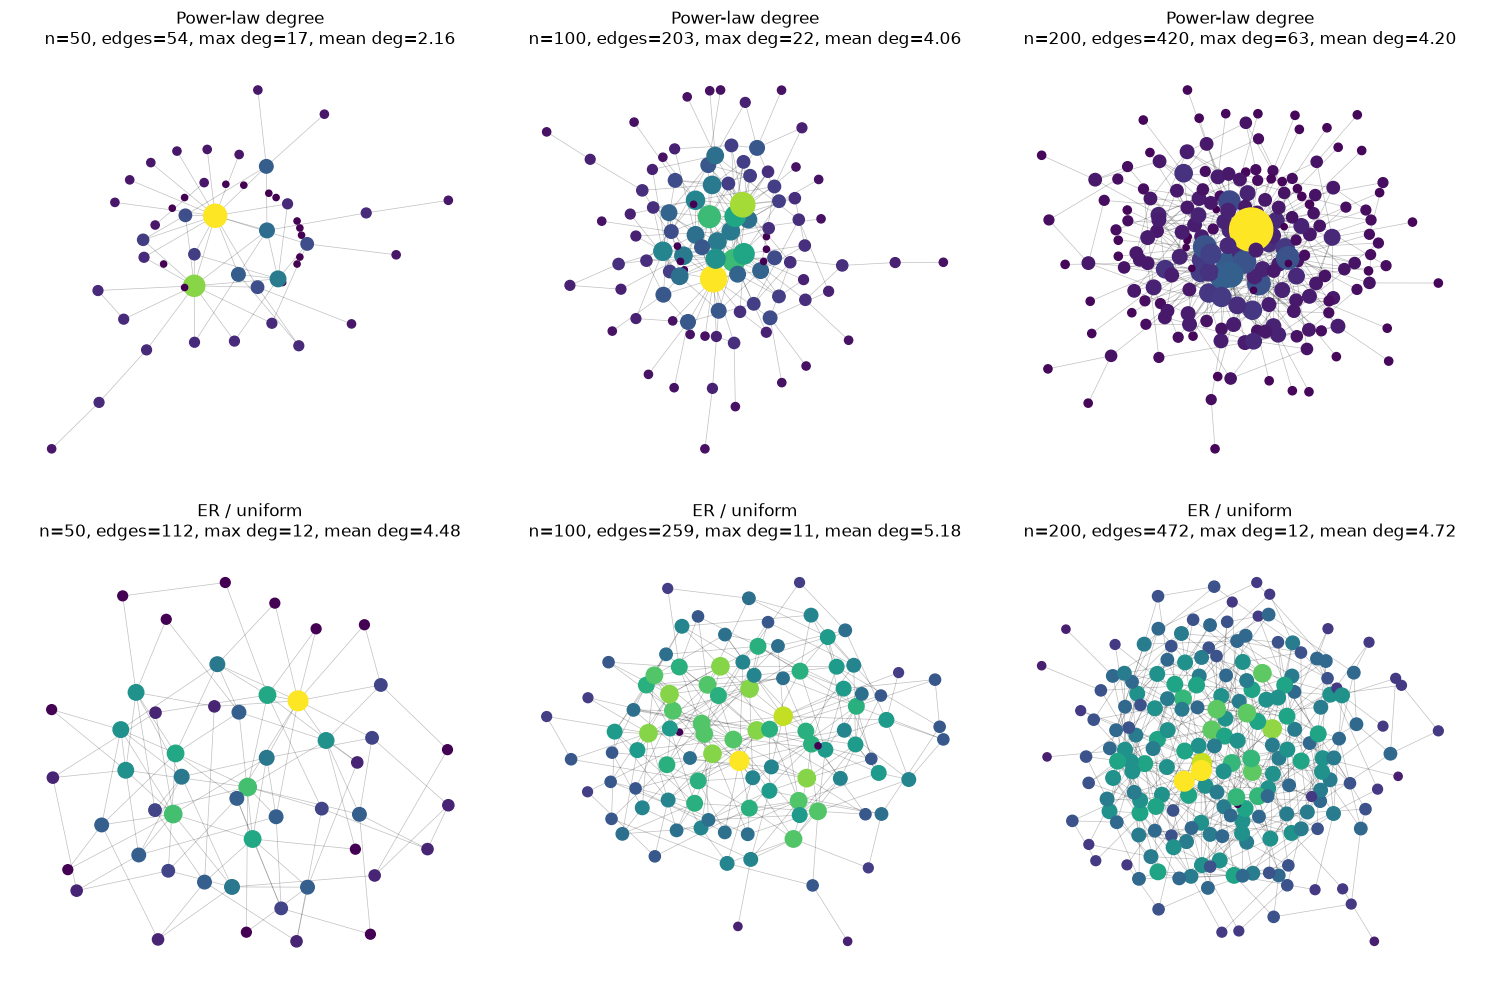

    n    target E[m]    power-law m       ER m
   50          125.0             54        112
  100          250.0            203        259
  200          500.0            420        472


In [30]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def sample_fitness_out_powerlaw_calibrated(n, gamma, avg_k_target, rng):
    x_min = (gamma - 2)/(gamma - 1) * np.sqrt(avg_k_target / (n - 1))  # initial guess
    u = rng.uniform(0, 1, n)
    x = x_min * (1 - u) ** (-1/(gamma - 1))

    # rescale x_min so that the ACTUAL sample mean matches what's needed,
    # rather than trusting the theoretical population mean
    x_bar_realized = x.mean()
    target_x_bar = np.sqrt(avg_k_target / (n - 1))
    scale = target_x_bar / x_bar_realized
    x = x * scale   # rescaling preserves the power-law shape (scale-invariance!)
    return x
def sample_fitness_out_powerlaw_v3(n, gamma, avg_k_target, rng):
    # draw shape first with an arbitrary x_min=1, fix scale after
    u = rng.uniform(0, 1, n)
    x_raw = (1 - u) ** (-1/(gamma - 1))   # x_min=1 for now

    # target: sum_{i<j} x_i x_j = target_m  (exact sparse-limit edge count)
    target_m = n * avg_k_target / 2
    pairwise_sum_raw = (x_raw.sum()**2 - (x_raw**2).sum()) / 2

    # x -> scale*x_raw implies pairwise_sum -> scale^2 * pairwise_sum_raw
    scale = np.sqrt(target_m / pairwise_sum_raw)
    x = scale * x_raw
    return x

def build_p_matrix(x):
    X = np.outer(x, x)
    P = X / (1 + X)
    np.fill_diagonal(P, 0)
    return P

def sample_powerlaw_graph(n, gamma, avg_k_target, rng):
    x = sample_fitness_out_powerlaw(n, gamma, avg_k_target, rng)
    P = build_p_matrix(x)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < P).astype(int)
    A = np.triu(A, 1); A = A + A.T
    return A, x
def sample_powerlaw_graph_v2(n, gamma, avg_k_target, rng):
    x = sample_fitness_out_powerlaw_v3(n, gamma, avg_k_target, rng)
    P = build_p_matrix(x)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < P).astype(int)
    A = np.triu(A, 1); A = A + A.T
    return A, x
def sample_er_graph(n, avg_k_target, rng):
    p = avg_k_target / (n - 1)   # matches expected average degree exactly (Eq. 16)
    rand_matrix = rng.uniform(0, 1, (n, n))
    A = (rand_matrix < p).astype(int)
    A = np.triu(A, 1); A = A + A.T
    return A

def visualize_graph(A, n, title, ax, color_by_degree=True, layout='kamada_kawai'):
    G = nx.from_numpy_array(A)
    k = np.array([d for _, d in G.degree()])
    pos = nx.kamada_kawai_layout(G) if layout=='kamada_kawai' else nx.spring_layout(G, seed=1, k=1.5/np.sqrt(n))

    node_sizes = 20 + 15*k
    node_colors = k if color_by_degree else 'steelblue'

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.5)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                                    node_color=node_colors, cmap='viridis')
    ax.set_title(f'{title}\nn={n}, edges={A.sum()//2}, max deg={k.max()}, mean deg={k.mean():.2f}')
    ax.axis('off')
    return k

# ============================================================
# Run comparison for n = 50, 100, 200, matched avg degree
# ============================================================

gamma = 2.2
avg_k_target = 5
rng = np.random.default_rng(0)

ns = [50, 100, 200]
fig, axes = plt.subplots(2, len(ns), figsize=(5*len(ns), 10))

for col, n in enumerate(ns):
    A_pl, x_pl = sample_powerlaw_graph_v2(n, gamma, avg_k_target, rng)
    A_er = sample_er_graph(n, avg_k_target, rng)

    visualize_graph(A_pl, n, 'Power-law degree', axes[0, col])
    visualize_graph(A_er, n, 'ER / uniform', axes[1, col])

plt.tight_layout()
plt.show()

# ============================================================
# Numeric check: expected vs realized edge counts
# ============================================================
print(f"{'n':>5} {'target E[m]':>14} {'power-law m':>14} {'ER m':>10}")
rng = np.random.default_rng(0)
for n in [50, 100, 200]:
    A_pl, _ = sample_powerlaw_graph_v2(n, gamma, avg_k_target, rng)
    A_er = sample_er_graph(n, avg_k_target, rng)
    target_m = n * avg_k_target / 2
    print(f"{n:>5} {target_m:>14.1f} {A_pl.sum()//2:>14} {A_er.sum()//2:>10}")